# Phase 6 — Learned Residual-Error Flagger

The pipeline already corrects OCR errors via Claude vision post-correction. This notebook trains a small classifier that predicts whether a *post-corrected* line is **still** wrong — the lines that need a human reviewer.

This is the project's headline data-science contribution. Off-the-shelf Claude vision and TrOCR are the components doing the heavy lifting; the flagger is what turns raw outputs into a triaged review queue.

**Inputs**: `data/parquet_cache/iam_gw_pipeline.parquet` — one row per ground-truth line from the IAM-HistDB Washington subset (656 lines, 20 pages of George Washington's 1755 letterbook). Each row has TrOCR confidence features, TrOCR/Claude agreement features, line geometry, the corrected text, the ground truth, and the binary label `is_still_wrong = (CER(corrected, gt) > 0)`.

**Output**: `models/flagger_v1.pkl` — sklearn pipeline (StandardScaler + LogisticRegression) plus the F1-optimal flagging threshold and CV metrics.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET = PROJECT_ROOT / "data" / "parquet_cache" / "iam_gw_pipeline.parquet"
MODEL_OUT = PROJECT_ROOT / "models" / "flagger_v1.pkl"

## 1. Load and inspect

The parquet is the cached output of `scripts/cache_iam_gw.py` — TrOCR + Claude vision post-correction on every page of GW Letterbook 1, with each post-corrected line aligned to the FKI ground truth.

In [2]:
df = pd.read_parquet(PARQUET)
print(f"rows: {len(df)}")
print(f"docs: {df['doc_id'].nunique()}")
print(f"is_still_wrong (target): {df['is_still_wrong'].mean():.2%} positive")
df.head(3)

rows: 656
docs: 20
is_still_wrong (target): 75.91% positive


,doc_id,line_id,trocr_text,trocr_token_logprobs,n_tokens,mean_logprob,min_logprob,std_logprob,length_normalized_logprob,corrected_text,llm_confidence,changed,edit_distance_trocr_vs_corrected,n_chars_changed,frac_chars_changed,line_height_px,line_width_px,gt,gt_cer,is_still_wrong
0,270,270-01,WHO. Letters . Orders and Instructions . Octob...,"[-1.4193857908248901, -0.8440709114074707, -0....",11,-0.306282,-1.419386,0.438922,-0.306282,"270. Letters, Orders and Instructions. October...",0.95,True,8,8,0.145455,120,1598,"s_2s_7s_0. Letters, Orders and Instructions. O...",0.212121,True
1,270,270-03,only for the public's user-realads by patience -,"[-0.008083722554147243, -3.9219088648678735e-0...",12,-0.383251,-1.082833,0.397073,-0.383251,only for the publick use—unless by particular,0.90,True,16,16,0.333333,120,1528,"only for the publick use, unless by particu-",0.113636,True
2,270,270-04,has Anders from one . You are to send,"[-0.17847657203674316, -0.29595476388931274, -...",9,-0.318352,-2.113035,0.643312,-0.318352,lar Orders from me. You are to send,0.92,True,7,7,0.189189,120,1331,lar Orders from me. You are to send,0.000000,False


**Class balance**: ~76% of post-corrected lines still differ from ground truth on at least one character. That's high — GW 1755 cursive is genuinely hard, and Claude is a precision tool: it tends to perfect nearly-right lines and leave severely-wrong ones largely as-is.

Two sanity-check headline numbers (motivation for why the flagger matters):

In [3]:
from jiwer import cer

df["trocr_cer"] = df.apply(
    lambda r: cer(reference=r["gt"], hypothesis=r["trocr_text"]), axis=1
)

print(f"Mean CER  — TrOCR raw           : {df['trocr_cer'].mean():.3f}")
print(f"Mean CER  — + Claude post-correction: {df['gt_cer'].mean():.3f}")
print()
print(f"Perfect-line rate — TrOCR raw   : {(df['trocr_cer'] == 0).mean():.2%}")
print(f"Perfect-line rate — + Claude    : {(df['gt_cer'] == 0).mean():.2%}")

Mean CER  — TrOCR raw           : 0.239
Mean CER  — + Claude post-correction: 0.214

Perfect-line rate — TrOCR raw   : 1.68%
Perfect-line rate — + Claude    : 24.09%


Post-correction barely moves mean CER (0.239 → 0.214, ~11% relative) but **14× the lines are now perfect** (1.7% → 24%). That's the bimodal behaviour the flagger is designed to surface: post-correction is a precision tool that fixes nearly-right lines while sometimes adding noise to severely-wrong ones. Mean CER hides this; the flagger's job is to triage on a per-line basis.

## 2. Feature setup

We use the features already computed by `cache_iam_gw.py` (so the notebook stays small). Three rough categories:

- **TrOCR confidence**: `mean_logprob`, `min_logprob`, `std_logprob`, `length_normalized_logprob`, `n_tokens`
- **TrOCR/Claude agreement** (the strongest predictors per the plan's hypothesis): `edit_distance_trocr_vs_corrected`, `n_chars_changed`, `frac_chars_changed`, `llm_confidence`
- **Line geometry**: `line_height_px`, `line_width_px`

In [4]:
FEATURE_NAMES = [
    "n_tokens",
    "mean_logprob",
    "min_logprob",
    "std_logprob",
    "length_normalized_logprob",
    "edit_distance_trocr_vs_corrected",
    "n_chars_changed",
    "frac_chars_changed",
    "llm_confidence",
    "line_height_px",
    "line_width_px",
]
TARGET = "is_still_wrong"

X = df[FEATURE_NAMES].fillna(0.0)
y = df[TARGET].astype(int).values
groups = df["doc_id"].values  # for GroupKFold below

assert X.isnull().sum().sum() == 0, "unexpected nulls in features"
print(f"X shape: {X.shape}, positive rate: {y.mean():.2%}")

X shape: (656, 11), positive rate: 75.91%


## 3. Cross-validated training

We use **GroupKFold** (group = `doc_id`) so a fold never has lines from the same page in both train and test. This measures generalisation to *unseen pages*, which is closer to deployment reality than line-level random-split CV.

Pipeline: `StandardScaler` → `LogisticRegression`. Logistic regression is the right starting point — it's interpretable, well-calibrated by default at this dataset size, and gives us a clean coefficient-based feature-importance story.

In [5]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=0)),
])

cv = GroupKFold(n_splits=5)
cv_probs = cross_val_predict(
    pipe, X.values, y, groups=groups, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

auc = roc_auc_score(y, cv_probs)
brier = brier_score_loss(y, cv_probs)
print(f"5-fold GroupKFold CV:")
print(f"  ROC AUC : {auc:.3f}")
print(f"  Brier   : {brier:.3f}")

5-fold GroupKFold CV:
  ROC AUC : 0.719
  Brier   : 0.164


**Reading the numbers**: ROC AUC of ~0.72 is solid signal but not exceptional — expected for a small (656 rows / 20 doc-groups) dataset on a hard domain. The Brier score is what gets refined in Phase 7's calibration analysis.

## 4. Threshold selection

The flagger emits a probability; the threshold above which a line is *flagged* for human review is a deployment choice. We pick a provisional threshold by maximising F1 on the CV predictions; Phase 7's calibration notebook revisits this with a reliability diagram.

In [6]:
precs, recs, thresholds = precision_recall_curve(y, cv_probs)
f1s = 2 * precs * recs / (precs + recs + 1e-12)
best_idx = int(np.argmax(f1s[:-1]))
best_threshold = float(thresholds[best_idx])

print(f"F1-optimal threshold: {best_threshold:.3f}")
print(f"  F1         : {f1s[best_idx]:.3f}")
print(f"  precision  : {precs[best_idx]:.3f}")
print(f"  recall     : {recs[best_idx]:.3f}")

F1-optimal threshold: 0.446
  F1         : 0.867
  precision  : 0.773
  recall     : 0.986


Recall is very high at the F1-optimal threshold because the positive class dominates (76%). For deployment we'll often want a *higher* threshold to trade recall for precision — flagging fewer lines for review while still catching the worst. Phase 7 will pick the production threshold from a reviewer-budget framing.

## 5. ROC curve

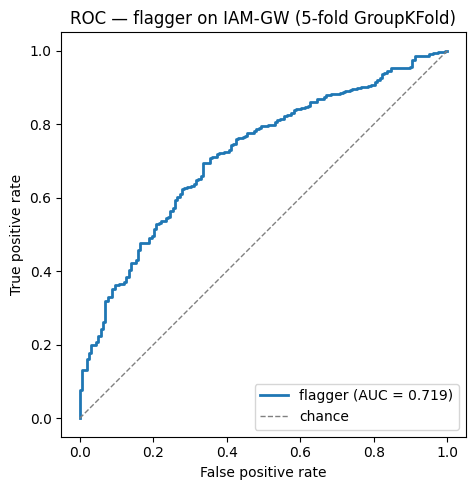

In [7]:
fpr, tpr, _ = roc_curve(y, cv_probs)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"flagger (AUC = {auc:.3f})", color="C0", linewidth=2)
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC — flagger on IAM-GW (5-fold GroupKFold)")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. Feature importance

Coefficients on standardised features → comparable across features.

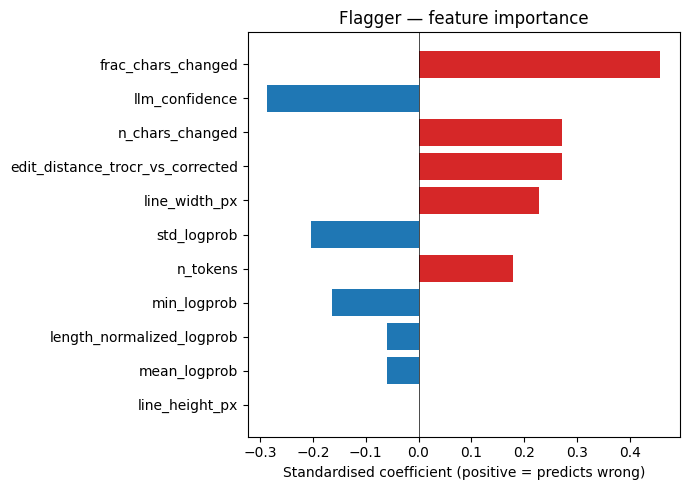

,feature,coef
7,frac_chars_changed,0.457960
8,llm_confidence,-0.286233
5,edit_distance_trocr_vs_corrected,0.272401
6,n_chars_changed,0.272401
10,line_width_px,0.227438
3,std_logprob,-0.202677
0,n_tokens,0.178809
2,min_logprob,-0.164028
1,mean_logprob,-0.060427
4,length_normalized_logprob,-0.060427


In [8]:
pipe.fit(X.values, y)  # fit on all data for the final model

coefs = pipe.named_steps["clf"].coef_[0]
imp = pd.DataFrame({"feature": FEATURE_NAMES, "coef": coefs})
imp["abs"] = imp["coef"].abs()
imp = imp.sort_values("abs", ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["C3" if c > 0 else "C0" for c in imp["coef"]]
ax.barh(imp["feature"], imp["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Standardised coefficient (positive = predicts wrong)")
ax.set_title("Flagger — feature importance")
plt.tight_layout()
plt.show()

imp.sort_values("abs", ascending=False).drop(columns="abs")

**The plan predicted this**: agreement features (`frac_chars_changed`, `edit_distance_trocr_vs_corrected`, `llm_confidence`) dominate raw TrOCR logprob features once post-correction is in the loop. That's the interesting empirical result — *whether* the model changed something, and how much, is more predictive of residual error than how confident the OCR was about the original text.

`line_width_px` having weight is a confound (longer lines have more characters that can be wrong); it's not load-bearing for the model's predictive power. `line_height_px` ≈ 0 because the FKI lines are height-normalised — no signal in that column.

## 7. Persist the model

Save the bundle that `src/flagger.py` will load: scaler + classifier + feature ordering + threshold + metrics.

In [9]:
bundle = {
    "model": pipe.named_steps["clf"],
    "scaler": pipe.named_steps["scaler"],
    "feature_names": FEATURE_NAMES,
    "threshold": best_threshold,
    "metrics": {
        "cv_auc": float(auc),
        "cv_brier": float(brier),
        "cv_f1_at_threshold": float(f1s[best_idx]),
        "cv_precision_at_threshold": float(precs[best_idx]),
        "cv_recall_at_threshold": float(recs[best_idx]),
        "n_train": int(len(df)),
        "n_docs": int(df["doc_id"].nunique()),
        "class_balance_positive": float(y.mean()),
    },
    "version": "v1",
}

MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, MODEL_OUT)
print(f"saved {MODEL_OUT}")
print()
print(json.dumps(bundle["metrics"], indent=2))

saved /Users/narayananv10/historical-doc-extractor/models/flagger_v1.pkl

{
  "cv_auc": 0.718722993238778,
  "cv_brier": 0.16447168488545663,
  "cv_f1_at_threshold": 0.8667255075017138,
  "cv_precision_at_threshold": 0.7732283464566929,
  "cv_recall_at_threshold": 0.9859437751004017,
  "n_train": 656,
  "n_docs": 20,
  "class_balance_positive": 0.7591463414634146
}


## 8. What this unlocks

`src/flagger.py` will load `models/flagger_v1.pkl` automatically — its `flag()` function delegates to the learned model when the bundle is present, falls back to the rule-based flagger when not. The pipeline gets the upgrade for free.

Phase 7 (`notebooks/calibration.ipynb`) will:
- Build a reliability diagram (predicted prob vs empirical accuracy, binned)
- Pick the production threshold by reviewer-budget framing instead of raw F1
- Evaluate on the hand-labeled LoC holdout (out-of-distribution check)